In [12]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [13]:
class BatsmanState(TypedDict):

    runs : int
    balls : int
    fours : int
    sixes : int

    sr: float
    bpb : float
    boundary_percent : float

    summary = str

In [35]:
def calculate_sr(state:BatsmanState):
    sr = (state['runs'] / state['balls']) * 100

    

    return {'sr' : sr}

In [36]:
def calculate_bpb(state:BatsmanState):

    bpb = (state['balls']/(state['fours'] + state['sixes']))

    

    return {'bpb' : bpb}

In [37]:
def calculate_boundary_percent(state:BatsmanState):

    boundary_percent = ((state['fours'] * 4) + (state['sixes'] * 6)) * 100

    

    return {'boundary_percent' : boundary_percent}

In [38]:
def calculate_summary(state:BatsmanState):
    summary = f"""
Strike Rate ---> {state['sr']} \n
Balls Per Boundary ---> {state['bpb']} \n
Boundary Percent ---> {state['boundary_percent']}


"""
    

    return {'summary' : summary}

In [39]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr' , calculate_sr)
graph.add_node('calculate_bpb' , calculate_bpb)
graph.add_node('calculate_boundary_percent' , calculate_boundary_percent)
graph.add_node('calculate_summary' , calculate_summary)


In [40]:
graph.add_edge(START , 'calculate_sr')
graph.add_edge(START , 'calculate_bpb')
graph.add_edge(START , 'calculate_boundary_percent')

graph.add_edge('calculate_sr' , 'calculate_summary')
graph.add_edge('calculate_bpb' , 'calculate_summary')
graph.add_edge('calculate_boundary_percent' , 'calculate_summary')

graph.add_edge('calculate_summary' , END)


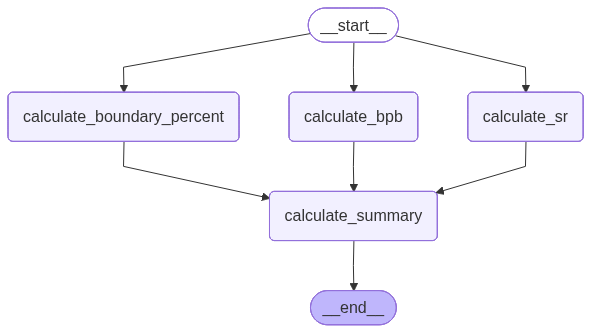

In [41]:
graph.compile()

In [42]:
workflow = graph.compile()

In [43]:
initial_state = {
    'runs' : 100,
    'balls' : 60,
    'fours' : 5,
    'sixes'  : 6
}

In [44]:
final_state = workflow.invoke(initial_state)

In [45]:
print(final_state)

{'runs': 100, 'balls': 60, 'fours': 5, 'sixes': 6, 'sr': 166.66666666666669, 'bpb': 5.454545454545454, 'boundary_percent': 5600}
